Name: Herve Tepongning Megnifo Student

Number: HT137724

Program: Business Intelligence Analyst

Course: Understanding and Sourcing Data

Assignment 5: Exploratory Data Analysis with Pandas

Titanic Dataset Exploratory Data Analysis

In [31]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# Task 1: Load the Titanic dataset
# TODO: Load the Titanic dataset from the following URL
# url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"

# df =pd.read_csv(url)

df=pd.read_csv('Titanic-Dataset.csv')

print(df.shape)


(891, 12)


In [33]:
"""
The dataset available through the provided URL contains only 8 attributes.
Therefore, I used the dataset provided on the assignment page.
The dataset has 891 rows and 12 columns.
"""

'\nThe dataset available through the provided URL contains only 8 attributes. \nTherefore, I used the dataset provided on the assignment page.\nThe dataset has 891 rows and 12 columns.\n'

In [34]:
# Task 2: Inspect the data
# TODO: Display the first 5 rows of the dataset
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [35]:
# TODO: Display the last 5 rows of the dataset
print(df.tail())

     PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  


In [36]:
# TODO: Display the data types of each column
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [37]:
# TODO: Display summary statistics of the numerical columns
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [39]:
# Task 3: Clean and preprocess the data

# TODO: Create a new categorical feature 'PclassCategory' from 'Pclass'

df['PclassCategory'] = df['Pclass'].map({1: 'First', 2: 'Second', 3: 'Third'})

print(df['PclassCategory'].head())



0    Third
1    First
2    Third
3    First
4    Third
Name: PclassCategory, dtype: object


In [40]:
# TODO: Create a new categorical feature 'CabinCategory' from 'Cabin'

df["CabinCategory"] = df["Cabin"].str[0].fillna("Unknown")
print(df['CabinCategory'].head())

print(df['CabinCategory'].value_counts())
#

0    Unknown
1          C
2    Unknown
3          C
4    Unknown
Name: CabinCategory, dtype: object
CabinCategory
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64


In [43]:
# TODO: Handle missing values in the 'Age' column (use mean age)
# Checking missing values
print(df.isnull().sum())

PassengerId         0
Survived            0
Pclass              0
Name                0
Sex                 0
Age                 0
SibSp               0
Parch               0
Ticket              0
Fare                0
Cabin             687
Embarked            2
PclassCategory      0
CabinCategory       0
dtype: int64


In [41]:
# Handle missing values in the 'Age' column (use mean age)

df['Age'].fillna(df['Age'].mean(), inplace=True)

print(df.isnull().sum())

PassengerId         0
Survived            0
Pclass              0
Name                0
Sex                 0
Age                 0
SibSp               0
Parch               0
Ticket              0
Fare                0
Cabin             687
Embarked            2
PclassCategory      0
CabinCategory       0
dtype: int64


/tmp/ipykernel_671/4119269460.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [45]:
# TODO: Create a 'Family' feature by combining 'SibSp' and 'Parch'

df['Family'] = df['SibSp'] + df['Parch']
print(df[['SibSp','Parch', 'Family']].head())

   SibSp  Parch  Family
0      1      0       1
1      1      0       1
2      0      0       0
3      1      0       1
4      0      0       0


In [46]:
# Task 4: Identify specific data points

# TODO: Find passengers with the highest fare
highest_fare_passengers = df[df['Fare'] == df['Fare'].max()]
print(highest_fare_passengers)



     PassengerId  Survived  Pclass                                Name  \
258          259         1       1                    Ward, Miss. Anna   
679          680         1       1  Cardeza, Mr. Thomas Drake Martinez   
737          738         1       1              Lesurer, Mr. Gustave J   

        Sex   Age  SibSp  Parch    Ticket      Fare        Cabin Embarked  \
258  female  35.0      0      0  PC 17755  512.3292          NaN        C   
679    male  36.0      0      1  PC 17755  512.3292  B51 B53 B55        C   
737    male  35.0      0      0  PC 17755  512.3292         B101        C   

    PclassCategory CabinCategory  Family  
258          First       Unknown       0  
679          First             B       1  
737          First             B       0  


In [48]:
# TODO: Find passengers with the largest family size
largest_family_passengers = df[df['Family'] == df['Family'].max()]
print(largest_family_passengers)

     PassengerId  Survived  Pclass                               Name     Sex  \
159          160         0       3         Sage, Master. Thomas Henry    male   
180          181         0       3       Sage, Miss. Constance Gladys  female   
201          202         0       3                Sage, Mr. Frederick    male   
324          325         0       3           Sage, Mr. George John Jr    male   
792          793         0       3            Sage, Miss. Stella Anna  female   
846          847         0       3           Sage, Mr. Douglas Bullen    male   
863          864         0       3  Sage, Miss. Dorothy Edith "Dolly"  female   

           Age  SibSp  Parch    Ticket   Fare Cabin Embarked PclassCategory  \
159  29.699118      8      2  CA. 2343  69.55   NaN        S          Third   
180  29.699118      8      2  CA. 2343  69.55   NaN        S          Third   
201  29.699118      8      2  CA. 2343  69.55   NaN        S          Third   
324  29.699118      8      2  CA. 2

In [54]:
# Task 5: Demonstrate Pandas Series and DataFrame functionalities

# TODO: Create a Pandas Series of passenger names
names_series = pd.Series(df['Name'])
print(names_series.head())

# TODO: Create a DataFrame of passenger names and ages
names_ages_df = df[['Name', 'Age']]
print(names_ages_df.head())

# TODO: Slice the DataFrame to show only passengers older than 50
older_passengers = df[df['Age'] > 50]

print('\nPassengers older than 50',older_passengers)


0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object
                                                Name   Age
0                            Braund, Mr. Owen Harris  22.0
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0
2                             Heikkinen, Miss. Laina  26.0
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0
4                           Allen, Mr. William Henry  35.0

Passengers older than 50      PassengerId  Survived  Pclass  \
6              7         0       1   
11            12         1       1   
15            16         1       2   
33            34         0       2   
54            55         0       1   
..           ...       ...     ...   
820          821         1       1   
829          83

In [58]:
# Task 6: Introduce multi-indexing

# TODO: Create a multi-index DataFrame grouped by 'Sex' and 'Pclass'
multi_index_df =  df.set_index(['Sex', 'Pclass'])

print(multi_index_df.head())


               PassengerId  Survived  \
Sex    Pclass                          
male   3                 1         0   
female 1                 2         1   
       3                 3         1   
       1                 4         1   
male   3                 5         0   

                                                            Name   Age  SibSp  \
Sex    Pclass                                                                   
male   3                                 Braund, Mr. Owen Harris  22.0      1   
female 1       Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1   
       3                                  Heikkinen, Miss. Laina  26.0      0   
       1            Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1   
male   3                                Allen, Mr. William Henry  35.0      0   

               Parch            Ticket     Fare Cabin Embarked PclassCategory  \
Sex    Pclass                                                         

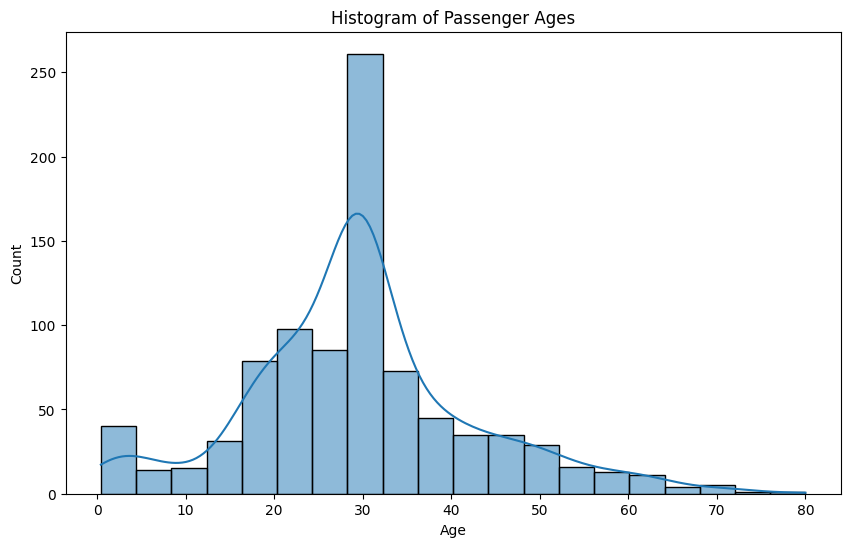

In [59]:
# Task 7: Visualizations

# TODO: Create a histogram of passenger ages
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Text(0, 0.5, 'Survival Rate')

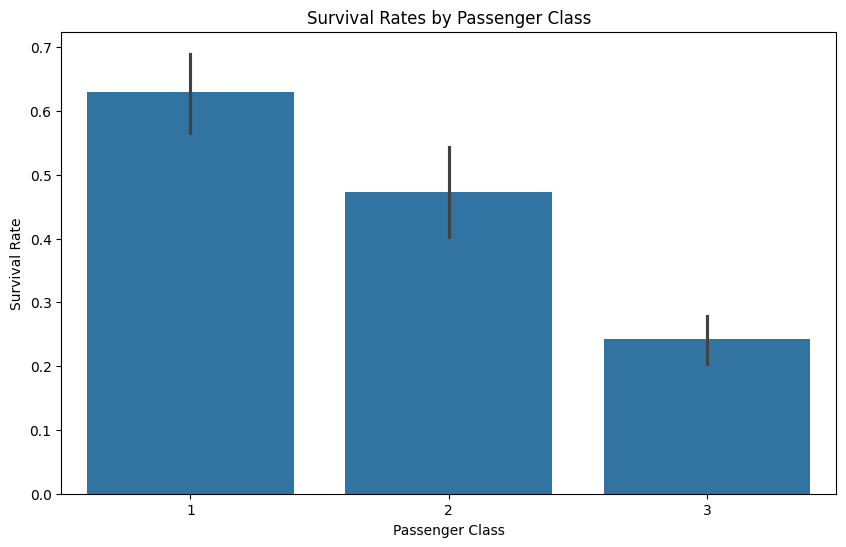

In [60]:
# TODO: Create a bar plot of survival rates by passenger class
plt.figure(figsize=(10, 6))
sns.barplot(x='Pclass', y='Survived', data=df)

plt.title('Survival Rates by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')

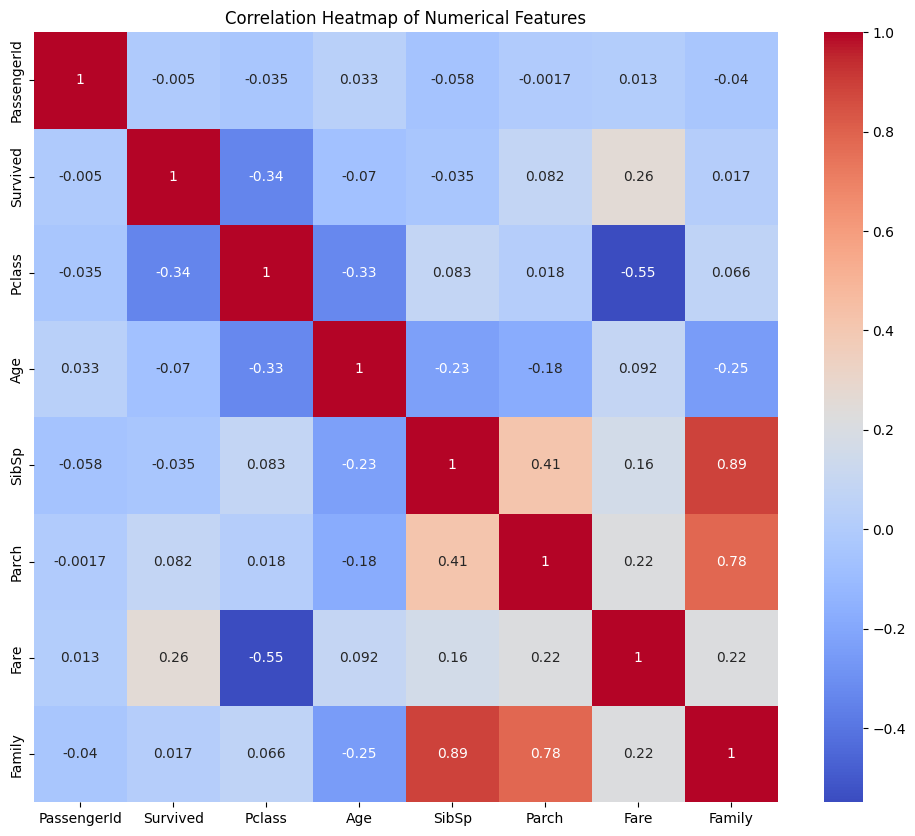

In [63]:
# TODO: Create a heatmap of correlation between numerical features
plt.figure(figsize=(12, 10))
# Select numerical
df_num= df.select_dtypes(include=[np.number])
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [ ]:
"""
Fare and Pclass show a moderate negative correlation (-0.55).
Pclass and Survived have a weaker negative correlation (-0.34).

"""

Text(0.5, 1.02, 'Pair Plot of Selected Features')

<Figure size 1200x1000 with 0 Axes>

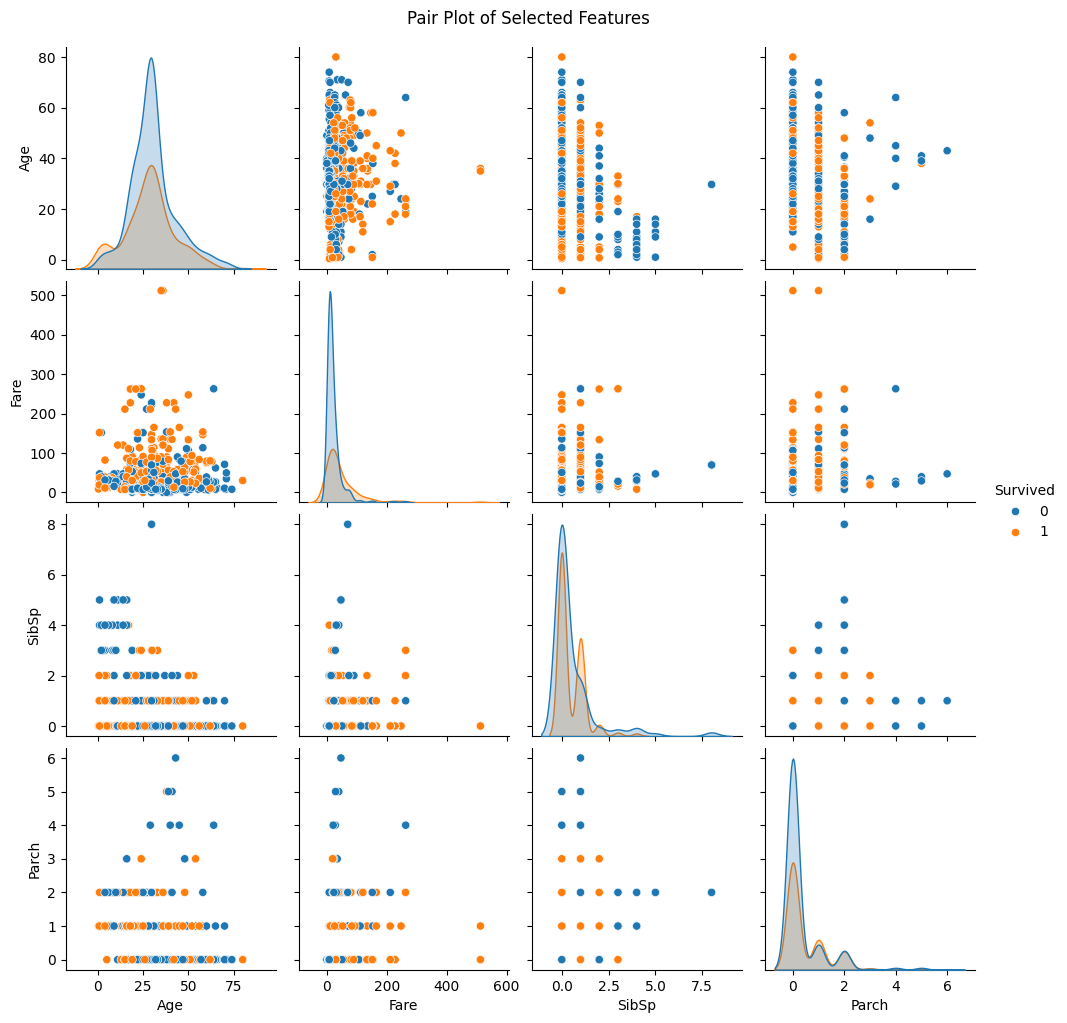

In [64]:
# TODO: Create a pair plot of 'Age', 'Fare', 'SibSp', and 'Parch', colored by 'Survived'
plt.figure(figsize=(12, 10))
sns.pairplot(df[['Age', 'Fare', 'SibSp', 'Parch', 'Survived']], hue='Survived')
plt.suptitle('Pair Plot of Selected Features', y=1.02)

In [71]:
# Task 8: Analyze survival rates

#TODO: Calculate and display survival rates by sex
survival_rate = df.groupby('Sex')['Survived'].mean()*100
print('Survival rates by sex')
print(survival_rate)

# TODO: Calculate and display survival rates by passenger class
survival_rate_passenger = df.groupby('Pclass')['Survived'].mean()*100

print('\nSurvival rates by passenger class')
print(survival_rate_passenger)

Survival rates by sex
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Survival rates by passenger class
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [ ]:
"""
About 74 out of every 100 female passengers survived,
while 19 out of every 100 male passengers survived
"""

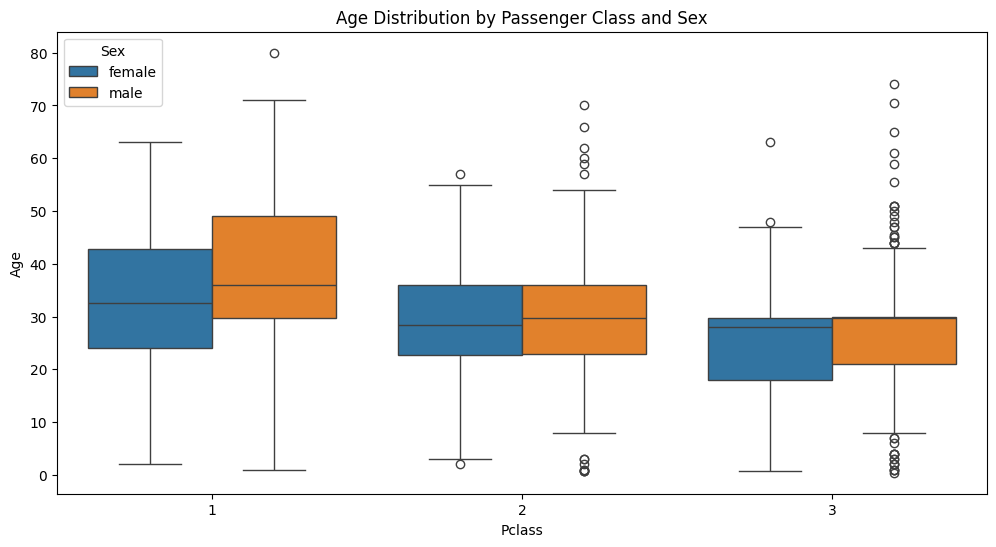

In [72]:
# Task 9: Analyze age distribution

# TODO: Create a box plot of age distribution by passenger class and sex
plt.figure(figsize=(12, 6))
sns.boxplot(x='Pclass', y='Age', hue='Sex', data=df)

plt.title('Age Distribution by Passenger Class and Sex')
plt.show()

In [ ]:
"""
Outlier : Outliers: Pclass 3, male passengers have multiple outliers
in the age distribution. The same pattern is observed for male passengers in Pclass 2.

Standard deviation: In Pclass 3, male passengers' ages are more concentrated around
the mean than female passengers' ages, indicating less variability in the male age distribution.

"""

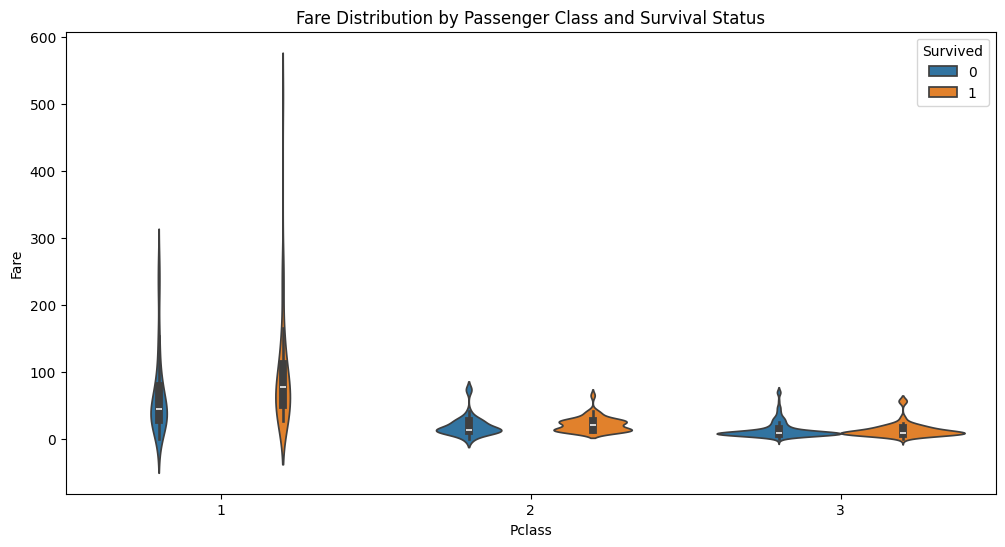

In [74]:

# TODO: Create a violin plot of fare distribution by passenger class and survival status
plt.figure(figsize=(12, 6))
sns.violinplot(x='Pclass', y='Fare', hue='Survived', data=df)

plt.title('Fare Distribution by Passenger Class and Survival Status')
plt.show()



In [76]:
print("EDA tasks completed.")



print('')

EDA tasks completed.

